In [ ]:
import os
import csv
import struct
import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal, optimize

plt.rcParams['font.family'] = 'Arial'

PATH = r"E:\fus-thermal\In_vivo_20260910_M01\v1_center_1300um_260910_154138-20260910T210526Z-1-001\v1_center_1300um_260910_154138"
CSV_PATH = r"E:\fus-thermal\In_vivo_20260910_M01\v1_center_1300um_260910_154138-20260910T210526Z-1-001\v1_center_1300um_260910_154138\thermal_experiment_invivo_T02_glass1layer_2.095MHz_V1_center_1300um_2026-09-10_15-41-36.csv"

P_KEY = 'P (MPa)'

DISPLAY_FS = 120  # Hz
OVERVIEW_FS = 4   # Hz

# Filter window for baseline estimate
BASELINE_WINDOW = 600.0  # s

# Triggered average properties
PRE = 0.5  # s, window length before each trigger burst onset
DURATION = 3.0  # s, window length after each trigger burst onset
BASELINE_PRE = 0.4  # s, pre-onset span averaged and subtracted from each trial

LOWPASS_FS = 30  # Hz, lowpass filter cutoff frequency for analog signal
GROUP_GAP = 1.0  # s, edges further apart than this start a new burst

# Double-exponential fit bounds
FIT_MIN_AMPLITUDE_C = 0.03  # degC
FIT_MAX_AMPLITUDE_C = 2.0  # degC

FIT_MAX_TAU_RISE = 1.0  # s

# Osensa fiber-optic temperature probe consts from Misi. todo: check
OSENSA_TZERO_C = 0.0
OSENSA_TSPAN_C = 100.0
OSENSA_RA_OHM = 149.3
OSENSA_I_MIN_A = 4e-3
OSENSA_I_MAX_A = 20e-3
OSENSA_GAIN_C_PER_V = OSENSA_TSPAN_C / (OSENSA_RA_OHM * (OSENSA_I_MAX_A - OSENSA_I_MIN_A))

In [103]:
def intan_layout(folder):
    """Sample rate (Hz), sample count and analog channel count for a recording.

    The rate comes straight out of info.rhd's fixed-offset header: magic number
    (4B) + version major/minor (2x int16) + sample_rate (float32). The channel
    count is inferred from the analogin.dat / time.dat file-size ratio (uint16
    vs int32 samples).
    """
    with open(f'{folder}/info.rhd', 'rb') as f:
        magic_number, = struct.unpack('<I', f.read(4))
        if magic_number != 0xc6912702:
            raise ValueError(f'{folder}/info.rhd is not a valid Intan RHD header')
        f.read(4)  # version major/minor, unused here
        fs, = struct.unpack('<f', f.read(4))

    time_bytes = os.path.getsize(f'{folder}/time.dat')
    analog_bytes = os.path.getsize(f'{folder}/analogin.dat')
    return fs, time_bytes // 4, round(2 * analog_bytes / time_bytes)


def load_analog_downsampled(folder, display_fs=DISPLAY_FS, channel=0, adc_scale=50.354e-6):
    """Mean-downsample one analogin channel straight off disk, in chunks.

    display_fs is the rate every later step (drift, filtering, trial
    extraction) works at; averaging each bin doubles as a boxcar lowpass.

    Returns (t_ds, v_ds, fs, ds_fs): seconds, Volts, raw rate, downsampled rate.
    time.dat is checked for continuity rather than read in full (it is another
    1 GB); if it ever has gaps, this assumption needs revisiting.
    """
    fs, n_samples, n_channels = intan_layout(folder)

    t_raw = np.memmap(f'{folder}/time.dat', dtype=np.int32, mode='r')
    if int(t_raw[-1]) - int(t_raw[0]) + 1 != n_samples:
        raise ValueError(f'{folder}/time.dat is not contiguous; sample times need reading in full')

    analog = np.memmap(f'{folder}/analogin.dat', dtype=np.uint16, mode='r')
    bin_size = max(int(round(fs / display_fs)), 1)
    n_bins = n_samples // bin_size

    v_ds = np.empty(n_bins, dtype=np.float64)
    chunk_bins = 100_000
    for start_bin in range(0, n_bins, chunk_bins):
        stop_bin = min(start_bin + chunk_bins, n_bins)
        block = np.asarray(
            analog[(start_bin * bin_size) * n_channels:(stop_bin * bin_size) * n_channels],
            dtype=np.float64)
        block = block.reshape(-1, n_channels)[:, channel]
        v_ds[start_bin:stop_bin] = block.reshape(stop_bin - start_bin, bin_size).mean(axis=1)
    v_ds *= adc_scale

    return (np.arange(n_bins) + 0.5) * bin_size / fs, v_ds, fs, fs / bin_size


def load_digital_rising_edges(folder, line):
    """Sample indices of every rising edge on one digitalin line, found in
    chunks off a memory map. Only the requested bit is ever unpacked.
    """
    words = np.memmap(f'{folder}/digitalin.dat', dtype=np.uint16, mode='r')

    edges = []
    previous = np.int8(0)
    chunk = 20_000_000
    for start in range(0, words.size, chunk):
        bits = ((np.asarray(words[start:start + chunk]) >> line) & 1).astype(np.int8)
        edges.append(np.where(np.diff(np.concatenate(([previous], bits))) == 1)[0] + start)
        previous = bits[-1]
    return np.concatenate(edges)


def active_digital_lines(folder):
    """Which digitalin bits are ever high, without unpacking the whole file."""
    words = np.memmap(f'{folder}/digitalin.dat', dtype=np.uint16, mode='r')
    acc = np.uint16(0)
    chunk = 20_000_000
    for start in range(0, words.size, chunk):
        acc |= np.bitwise_or.reduce(np.asarray(words[start:start + chunk]))
    return np.where(((int(acc) >> np.arange(16)) & 1).astype(bool))[0]


def volts_to_degc(v):
    """Osensa probe voltage (analogin channel 0, across burden resistor RA) to
    degC. Linear 4-20 mA current-loop scaling, matching the vendor's MATLAB:
        temp = Tzero + (V - Imin*RA) / (Imax*RA - Imin*RA) * Tspan
    """
    v_min = OSENSA_I_MIN_A * OSENSA_RA_OHM
    v_max = OSENSA_I_MAX_A * OSENSA_RA_OHM
    return OSENSA_TZERO_C + (v - v_min) / (v_max - v_min) * OSENSA_TSPAN_C
def double_exp(t, t0, amplitude, tau_rise, tau_decay, offset):
    """Rise-times-decay double-exponential transient, for fitting to data.

    Same shape as the double_exp used in figure-double-exponentials.ipynb
    ((1 - exp(-t/tau_rise)) * exp(-t/tau_decay), zero before onset), but
    parameterized with t0/amplitude/offset instead of being normalized to
    [0, 1], so it can be fit directly to a real (unnormalized) trace.
    """
    dt = t - t0
    y = np.zeros_like(t)
    m = dt >= 0
    y[m] = (1 - np.exp(-dt[m] / tau_rise)) * np.exp(-dt[m] / tau_decay)
    return offset + amplitude * y


def double_exp_peak(t, t0, peak, tau_rise, tau_decay, offset):
    """double_exp renormalized so that 'peak' is the transient's actual peak
    height rather than a scale factor on the un-normalized shape.

    This is what is actually fit. In the raw parameterization the amplitude and
    tau_rise are degenerate whenever tau_rise is long compared with the window
    -- (1 - exp(-t/tr)) -> t/tr, so amplitude and tr trade off exactly -- and
    the fit runs away to its amplitude bound with a meaningless multi-second
    rise time. Dividing the shape by its own peak removes that runaway and
    makes the reported amplitude directly comparable to the measured peak.

    Setting the derivative to zero gives exp(-t/tau_rise) = tr / (tr + td) at
    the maximum, hence the closed-form peak height below.
    """
    w = tau_rise / (tau_rise + tau_decay)
    unit_peak = (1 - w) * w ** (tau_rise / tau_decay)
    return double_exp(t, t0, peak / unit_peak, tau_rise, tau_decay, offset)


def fit_double_exp(t_window, trace):
    """Fit double_exp_peak to one mean transient, or return None if the
    transient is at the noise floor or the fit does not converge.

    The fit describes these transients well (R^2 ~ 0.98), but on this data
    tau_rise is not identifiable: the probe rises almost linearly while the
    0.2 s stimulus is on, which is the tau_rise -> infinity limit of the model,
    so tau_rise sits on its FIT_MAX_TAU_RISE bound for most conditions. t0
    (~170 ms here) absorbs the probe's onset lag. Quote the peak, the time to
    peak and tau_decay; treat a saturated tau_rise as a lower bound.
    """
    observed_peak = trace[t_window >= 0].max()
    if observed_peak < FIT_MIN_AMPLITUDE_C:
        return None
    p0 = [0.0, observed_peak, 0.1, 0.3, 0.0]
    bounds = ([-0.2, 0, 1e-3, 1e-2, -0.05],
              [0.5, min(5 * observed_peak, FIT_MAX_AMPLITUDE_C), FIT_MAX_TAU_RISE, 5.0, 0.05])
    try:
        popt, _ = optimize.curve_fit(double_exp_peak, t_window, trace, p0=p0, bounds=bounds)
    except RuntimeError:
        return None
    return popt

In [104]:
t_ds, v_ds, fs, ds_fs = load_analog_downsampled(PATH)
temp_ds = volts_to_degc(v_ds)  # analogin channel 0 is the temp probe

trigger_line = int(active_digital_lines(PATH)[0])
edge_times = load_digital_rising_edges(PATH, trigger_line) / fs

# CLaude figured out how to identify the groups this way
burst_ids = np.concatenate(([0], np.cumsum(np.diff(edge_times) > GROUP_GAP)))
onset_times = edge_times[np.concatenate(([0], np.where(np.diff(burst_ids) == 1)[0] + 1))]
n_trials = onset_times.size

# Trial table
with open(CSV_PATH, newline='') as f:
    csv_rows = list(csv.DictReader(f))
csv_t0 = datetime.datetime.fromisoformat(csv_rows[0]['timestamp'])
table = {'timestamp': np.array([(datetime.datetime.fromisoformat(r['timestamp']) - csv_t0).total_seconds()
                                for r in csv_rows])}
for column in csv_rows[0]:
    if column != 'timestamp':
        table[column] = np.array([float(r[column]) for r in csv_rows])

axis_values = {k: np.unique(np.round(v, 6)) for k, v in table.items() if k != 'timestamp'}
if n_trials != len(csv_rows):
    raise ValueError(
        f'{n_trials} trigger bursts but {len(csv_rows)} CSV rows -- cannot pair trials positionally. '
        f'Check GROUP_GAP, or trim the CSV/recording to the overlapping trials.')

clock_offset = onset_times - table['timestamp']
clock_drift = clock_offset.max() - clock_offset.min()
print(f'{n_trials} trigger bursts on DIN-{trigger_line:02d} paired with {len(csv_rows)} CSV rows')
print(f'  recording {t_ds[-1] / 3600:.2f} h at {fs:.0f} Hz, analysed at {ds_fs:.2f} Hz')
print(f'  host-clock offset {clock_offset.mean():.2f} s, drift over the session {clock_drift * 1000:.0f} ms')
if clock_drift > 1.0:
    print('  WARNING: >1 s of relative drift -- check the burst/row pairing before trusting the pairing')

# Lowpass the whole continuous trace before slicing into trials
sos = signal.butter(4, LOWPASS_FS, btype='low', fs=ds_fs, output='sos')
temp_filtered = signal.sosfiltfilt(sos, temp_ds)

pre_samples = int(round(PRE * ds_fs))
post_samples = int(round(DURATION * ds_fs))
baseline_samples = int(round(BASELINE_PRE * ds_fs))
t_window = (np.arange(pre_samples + post_samples) - pre_samples) / ds_fs

onset_samples = np.searchsorted(t_ds, onset_times)
valid = (onset_samples >= pre_samples) & (onset_samples + post_samples <= temp_filtered.size)
if not valid.all():
    print(f'  {(~valid).sum()} trial(s) dropped: window runs off the end of the recording')

trials = np.full((n_trials, t_window.size), np.nan)
for i in np.where(valid)[0]:
    window = temp_filtered[onset_samples[i] - pre_samples:onset_samples[i] + post_samples]
    trials[i] = window - window[pre_samples - baseline_samples:pre_samples].mean()

pulse_offsets = [edge_times[burst_ids == i] - onset_times[i] for i in range(n_trials)]

120 trigger bursts on DIN-00 paired with 120 CSV rows
  recording 1.01 h at 20000 Hz, analysed at 119.76 Hz
  host-clock offset 35.37 s, drift over the session 28 ms


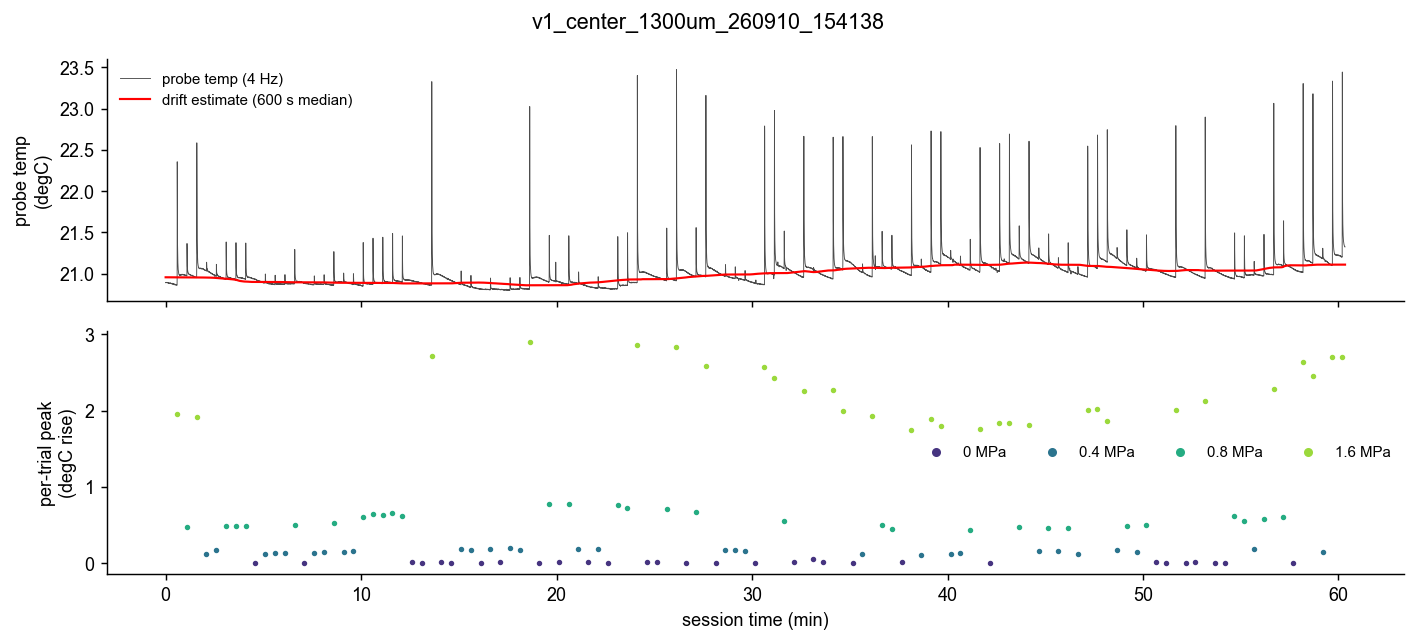

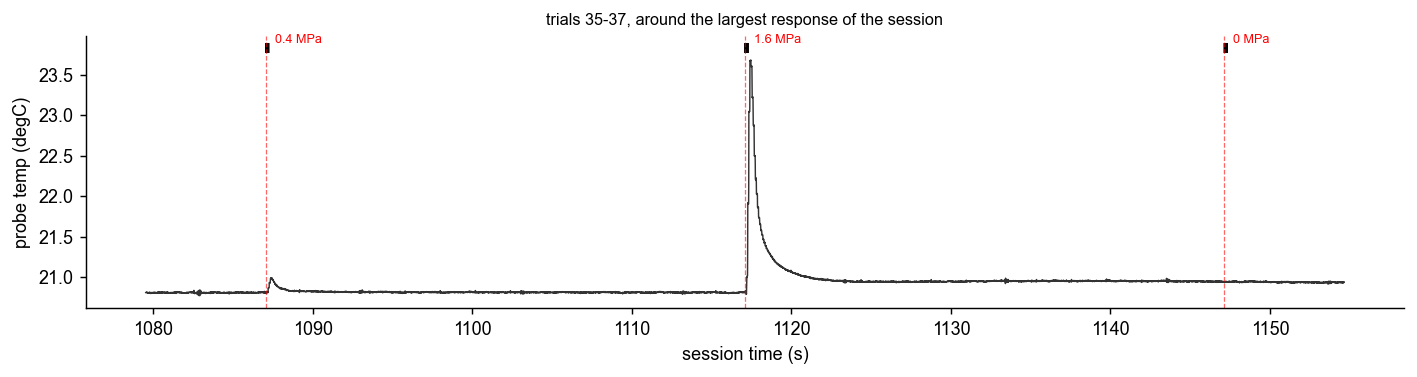

In [105]:
overview_bin = max(int(round(ds_fs / OVERVIEW_FS)), 1)
n_overview = temp_ds.size // overview_bin
t_ov = t_ds[:n_overview * overview_bin].reshape(n_overview, overview_bin).mean(axis=1)
temp_ov = temp_ds[:n_overview * overview_bin].reshape(n_overview, overview_bin).mean(axis=1)
drift = ndimage.median_filter(temp_ov, size=int(round(BASELINE_WINDOW * OVERVIEW_FS)), mode='reflect')  # Baseline estimate

post = t_window >= 0
trial_peaks = np.nanmax(trials[:, post], axis=1)
pressures = axis_values[P_KEY]
trial_pressure = np.round(table[P_KEY], 6)  # trial -> swept pressure, rounded to match axis_values
pressure_color = {p: plt.get_cmap('viridis')(0.15 + 0.7 * i / max(len(pressures) - 1, 1))
                  for i, p in enumerate(pressures)}

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(11, 5), dpi=130)

axes[0].plot(t_ov / 60, temp_ov, lw=0.5, color='0.3', label=f'probe temp ({OVERVIEW_FS} Hz)')
axes[0].plot(t_ov / 60, drift, lw=1.2, color='r', label=f'drift estimate ({BASELINE_WINDOW:g} s median)')
axes[0].set_ylabel('probe temp\n(degC)')
axes[0].legend(fontsize='small', frameon=False)

for pressure, color in pressure_color.items():
    m = trial_pressure == pressure
    axes[1].plot(onset_times[m] / 60, trial_peaks[m], '.', ms=4, color=color, label=f'{pressure:g} MPa')
axes[1].set_ylabel('per-trial peak\n(degC rise)')
axes[1].legend(fontsize='small', frameon=False, ncol=len(pressure_color), markerscale=2)
axes[1].set_xlabel('session time (min)')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle(os.path.basename(PATH))
fig.tight_layout()
plt.show()

# A few consecutive trials for triage
zoom_span = 2.5 * float(np.median(np.diff(onset_times)))  # s
zoom_center = onset_times[np.nanargmax(trial_peaks)]
m = (t_ds >= zoom_center - zoom_span / 2) & (t_ds <= zoom_center + zoom_span / 2)
shown = np.where((onset_times >= t_ds[m][0]) & (onset_times <= t_ds[m][-1]))[0]

fig, ax = plt.subplots(figsize=(11, 3), dpi=130)
ax.plot(t_ds[m], temp_ds[m], lw=0.8, color='0.2')
tick_y = temp_ds[m].max() + 0.05 * np.ptp(temp_ds[m])
for i in shown:
    pulses = onset_times[i] + pulse_offsets[i]
    ax.plot(pulses, np.full_like(pulses, tick_y), 'k|', ms=6, alpha=0.6)
    ax.axvline(onset_times[i], color='r', ls='--', lw=0.7, alpha=0.6)
    ax.annotate(f'{table[P_KEY][i]:g} MPa', (onset_times[i], tick_y), fontsize=7,
                xytext=(5, 1), textcoords='offset points', ha='left', va='bottom', color='r')
ax.set_xlabel('session time (s)')
ax.set_ylabel('probe temp (degC)')
label = f'trial {shown.min()}' if shown.size == 1 else f'trials {shown.min()}-{shown.max()}'
ax.set_title(f'{label}, around the largest response of the session', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()

In [106]:
# Triggered averages, one condition per pressure

averages = {}
for pressure in pressures:
    idx = np.where(valid & (trial_pressure == pressure))[0]
    if idx.size == 0:
        continue
    block = trials[idx]
    mean = block.mean(axis=0)
    try:
        popt = fit_double_exp(t_window, mean)
    except Exception as e:
        print(f"Failed to fit double exponential for pressure {pressure}: {e}")
        popt = None
    averages[pressure] = dict(
        idx=idx, n=idx.size, trials=block, mean=mean,
        sem=block.std(axis=0, ddof=1) / np.sqrt(idx.size),
        peak=mean[post].max(), t_peak=t_window[post][np.argmax(mean[post])], fit_popt=popt,
        fit_r2=(1 - (mean - double_exp_peak(t_window, *popt)).var() / mean.var()
                if popt is not None else np.nan))

print(f'{len(averages)} pressures, {min(a["n"] for a in averages.values())}-'
      f'{max(a["n"] for a in averages.values())} trials each')

# Per figure scaling
TRACE_YLIM = (min(a['mean'].min() for a in averages.values()) - 0.02,
              max(a['mean'].max() for a in averages.values()) * 1.15)

Failed to fit double exponential for pressure 1.6: Initial guess is outside of provided bounds
4 pressures, 30-30 trials each


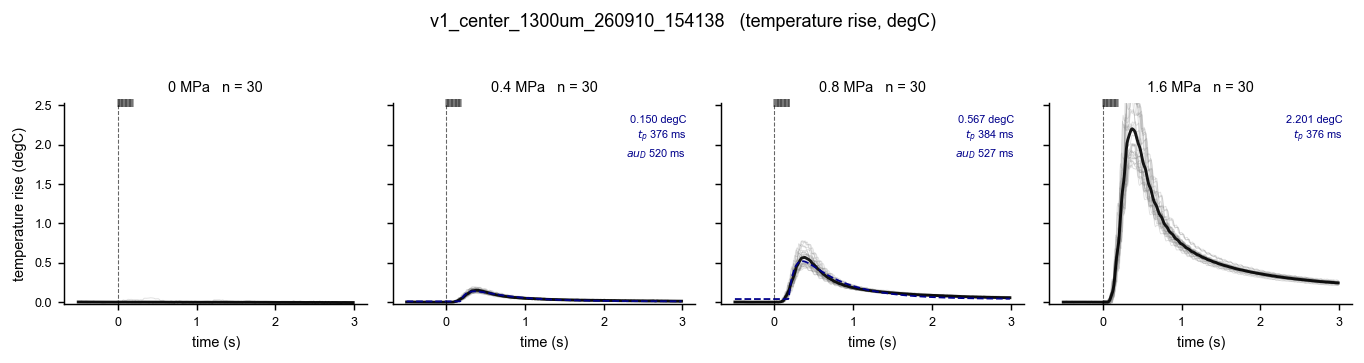

In [107]:
# One panel per pressure
fig, axes = plt.subplots(1, len(averages), sharex=True, sharey=True, squeeze=False, dpi=130,
                         figsize=(2.4 * len(averages) + 1.0, 2.8))
axes = axes[0]
axes[0].set_ylim(*TRACE_YLIM)

for ax, (pressure, average) in zip(axes, averages.items()):
    pulses = pulse_offsets[average['idx'][0]]
    ax.plot(pulses, np.ones_like(pulses), 'k|', ms=4, alpha=0.35, clip_on=False,
            transform=ax.get_xaxis_transform())
    ax.plot(t_window, average['trials'].T, color='grey', alpha=0.25, lw=0.5)
    ax.plot(t_window, average['mean'], color='black', lw=1.6, alpha=0.9)
    if average['fit_popt'] is not None:
        ax.plot(t_window, double_exp_peak(t_window, *average['fit_popt']),
                color='darkblue', lw=1.0, ls='--')
    ax.axvline(0, color='k', ls='--', lw=0.6, alpha=0.6)

    if average['peak'] > FIT_MIN_AMPLITUDE_C:
        text = f'{average["peak"]:.3f} degC\n$t_p$ {average["t_peak"] * 1000:.0f} ms'
        if average['fit_popt'] is not None:
            text += f'\n$\tau_D$ {average["fit_popt"][3] * 1000:.0f} ms'
        ax.text(0.97, 0.94, text, transform=ax.transAxes, ha='right', va='top',
                fontsize=6, color='darkblue', linespacing=1.3)

    ax.tick_params(labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f'{pressure:g} MPa   n = {average["n"]}', fontsize=8)
    ax.set_xlabel('time (s)', fontsize=8)

axes[0].set_ylabel('temperature rise (degC)', fontsize=8)
fig.suptitle(os.path.basename(PATH) + '   (temperature rise, degC)', fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

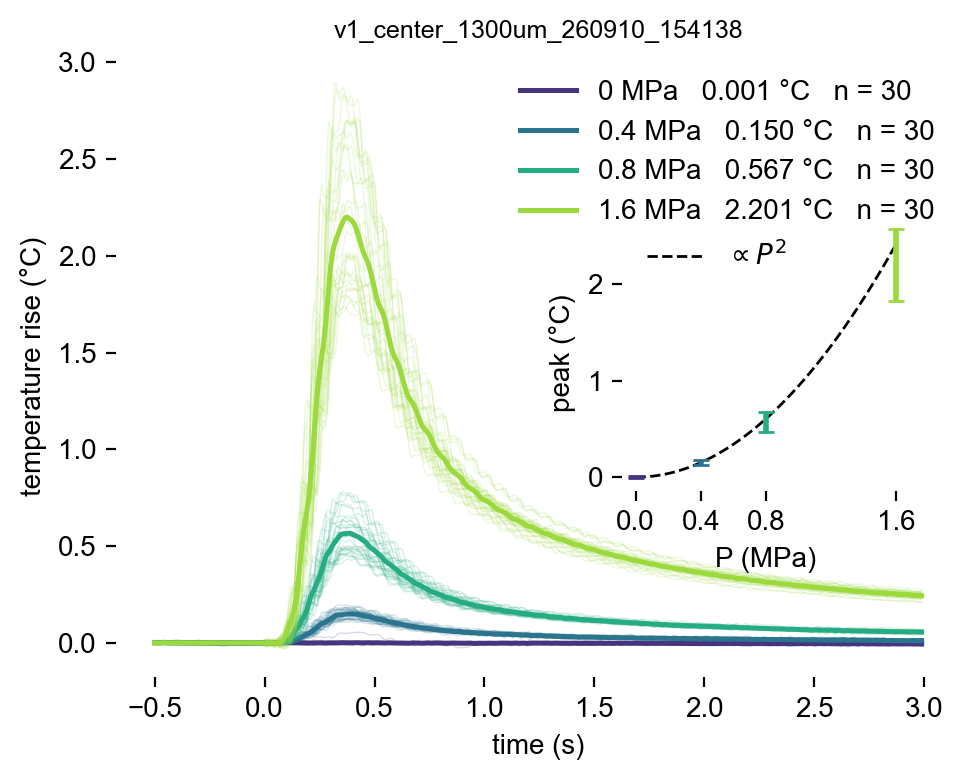

In [108]:
# The pressure ramp at the probe

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

for pressure, average in averages.items():
    color = pressure_color[pressure]
    ax.plot(t_window, average['trials'].T, color=color, alpha=0.18, lw=0.5)
    ax.plot(t_window, average['mean'], color=color, lw=1.8,
            label=f'{pressure:g} MPa   {average["peak"]:.3f} \N{DEGREE SIGN}C   n = {average["n"]}')

ax.set_xlabel('time (s)')
ax.set_ylabel(f'temperature rise (\N{DEGREE SIGN}C)')
ax.legend(frameon=False, loc='upper right')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(os.path.basename(PATH), fontsize=9)

# Inset: peak rise against pressure, against the P^2 that free-field absorption
# predicts. Error bars are the spread of single trials at the mean's peak sample.
inset = ax.inset_axes([0.60, 0.30, 0.34, 0.44])
p_measured = np.array(sorted(averages))
rise_measured = np.array([averages[p]['peak'] for p in p_measured])
p_line = np.linspace(0, p_measured.max(), 100)
inset.plot(p_line, 1.1 * rise_measured[-1] * (p_line / p_measured.max()) ** 2,
           color='black', lw=1.0, ls='--', label='$\propto P^2$')
for pressure in p_measured:
    average = averages[pressure]
    peak_index = np.flatnonzero(post)[np.argmax(average['mean'][post])]
    trial_rises = average['trials'][:, peak_index]
    inset.errorbar(pressure, trial_rises.mean(), yerr=trial_rises.std(ddof=1),
                   color=pressure_color[pressure], marker='None', ms=1.0, lw=2.0,
                   capsize=3, zorder=10)
inset.legend(frameon=False)
inset.plot(p_measured, rise_measured, linestyle='None', color='k', lw=1.0, zorder=0)
inset.set_xlabel(P_KEY)
inset.set_ylabel(f'peak (\N{DEGREE SIGN}C)')
inset.set_xticks(p_measured)
inset.tick_params()
for spine in inset.spines.values():
    spine.set_visible(False)

fig.tight_layout()
plt.show()